# **Trabajo Parcial**

**Integrantes:**
- Angel Gabriel Diaz Chavez (u20221c424)
- Williams Giusseppi Claros Simon (u202312907)

Librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

# Carga e inspeccion de datos

In [2]:
df = pd.read_csv('datos/twitter_reddit_posts.csv', encoding='utf-8')
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
clases_top3 = ['Depression', 'Normal', 'Suicidal']
df = df[df['status'].isin(clases_top3)].copy()

print(f"Dataset filtrado a {len(clases_top3)} categorías: {clases_top3}")
print(f"Filas resultantes: {df.shape[0]}")
print()
print(df['status'].value_counts())

Dataset filtrado a 3 categorías: ['Depression', 'Normal', 'Suicidal']
Filas resultantes: 42407

status
Normal        16351
Depression    15404
Suicidal      10652
Name: count, dtype: int64


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 42407 entries, 733 to 48288
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  42407 non-null  str  
 1   statement   42398 non-null  str  
 2   status      42407 non-null  str  
dtypes: str(3)
memory usage: 23.1 MB


In [5]:
df.shape

(42407, 3)

# Valores vacios o 0

In [6]:
df.isna().sum()

Unnamed: 0    0
statement     9
status        0
dtype: int64

In [7]:
(df == 0).sum()

Unnamed: 0    0
statement     0
status        0
dtype: int64

# Valores Unicos y Repetidos

In [8]:
valores_unicos = df['statement'].nunique()
filas_duplicadas = df['statement'].duplicated(keep='first').sum()

print(f"Cantidad de frases únicas: {valores_unicos}")
print(f"Cantidad de filas repetidas: {filas_duplicadas}")

if filas_duplicadas > 0:
    print("\n--- DETALLE DE LAS FRASES REPETIDAS ---")

    df_agrupado = df.groupby('statement').agg(
        Cantidad_de_apariciones=('statement', 'size'),
        Cantidad_de_categorias=('status', 'nunique'),
        Status_asociado=('status', lambda x: ', '.join(x.dropna().astype(str).unique()))
    ).reset_index()

    df_repetidos_todos = df_agrupado[df_agrupado['Cantidad_de_apariciones'] > 1].sort_values(
        by='Cantidad_de_apariciones', ascending=False
    )

    solo_ruido     = (df_repetidos_todos['Cantidad_de_categorias'] == 1).sum()
    multicategoria = (df_repetidos_todos['Cantidad_de_categorias'] > 1).sum()

    print(f"Frases distintas que se repiten: {len(df_repetidos_todos)}")
    print(f"  → Misma categoría (duplicados puros): {solo_ruido}")
    print(f"  → En múltiples categorías (conservar una por cat.): {multicategoria}")
    print("\nTop 20 frases más repetidas:")

    df_top_20 = df_repetidos_todos.head(20).copy()
    df_top_20.rename(columns={'statement': 'Frase (statement)'}, inplace=True)
    display(df_top_20[['Frase (statement)', 'Cantidad_de_apariciones', 'Cantidad_de_categorias', 'Status_asociado']])

else:
    print("\nEl dataset no tiene frases repetidas.")

Cantidad de frases únicas: 41763
Cantidad de filas repetidas: 643

--- DETALLE DE LAS FRASES REPETIDAS ---
Frases distintas que se repiten: 451
  → Misma categoría (duplicados puros): 441
  → En múltiples categorías (conservar una por cat.): 10

Top 20 frases más repetidas:


,Frase (statement),Cantidad_de_apariciones,Cantidad_de_categorias,Status_asociado
40445,what do you mean?,22,1,Normal
41010,why not?,16,1,Normal
153,#NAME?,14,3,"Normal, Depression, Suicidal"
36143,ni-ki best boy,11,1,Normal
40485,what happened?,10,1,Normal
40994,why is that?,9,1,Normal
32673,i want to be dead ive been suicidal for year i...,8,1,Depression
26813,being border restricted victim day by day we g...,8,1,Depression
34956,like what?,7,1,Normal
35333,me too.,7,1,Normal


--- ESTADÍSTICAS DE LONGITUD DE TEXTOS ---


count    42407.000000
mean       104.311505
std        160.587318
min          1.000000
25%         12.000000
50%         47.000000
75%        134.000000
max       5248.000000
Name: word_count, dtype: float64

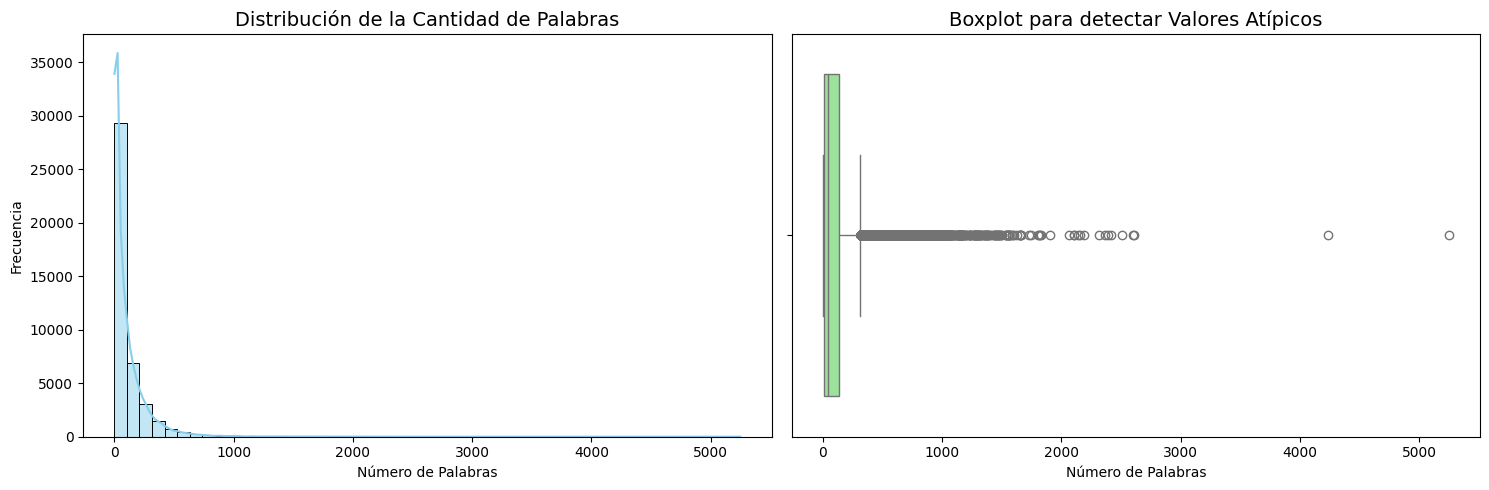

--- DISTRIBUCIÓN POR RANGOS DE PALABRAS ---


,Rango,Cantidad,% del total
0,1-5,4297,10.13
1,6-10,5139,12.12
2,11-20,5728,13.51
3,21-50,6682,15.76
4,51-100,6915,16.31
5,101-200,6953,16.40
6,201-500,5523,13.02
7,501-1000,989,2.33
8,1000+,181,0.43


--- MUESTRA: TEXTOS MUY CORTOS (1-2 palabras) por categoría ---

[Depression]


,statement,status,word_count
16887,aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa...,Depression,2
20169,[ webshealth.com,Depression,2
38824,pls answerrr,Depression,2
38948,ahhhhhhhhhhhhh,Depression,1
39639,fuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuck,Depression,1



[Normal]


,statement,status,word_count
738,No comeback~,Normal,2
746,"annoyed ,",Normal,2
747,Hurry bruh!,Normal,2
753,chat.,Normal,1
762,Room cleaning,Normal,2



[Suicidal]


,statement,status,word_count
8269,alskjdalskdjalskdjalskdjalskdjalskjd aslkdjasl...,Suicidal,2
10342,9111 10335,Suicidal,2
10609,Please help,Suicidal,2
13928,FUUUUUUUUCCCCCCKKKK! AAHHHHHHHHHHHHHHHHHHHHHHH...,Suicidal,2
24163,Suicide=peace Peace,Suicidal,2


--- MUESTRA: TEXTOS MUY LARGOS (top 5) ---
[5248 palabras | Suicidal]
I have only 1 person I can somewhat open to but I have only done so to a certain extent and try to refrain from doing it at all for the most part. I feel guilty as if I am bothering them with unfairly

[4239 palabras | Depression]
it doesn t matter anymore i m going to copy and paste my note it really doesn t matter i know i m spilling my gut out oh who care now i m lonely i m a solider to my self pride status something i fail 

[2612 palabras | Depression]
I no longer know what else to do but write this. I am not even sure what I expect to come of it except for hopefully support and sympathy and trying to see light at the end of this dark tunnel. I will

[2599 palabras | Depression]
I constantly repeat to myself that I have never really been given a fighting chance. Quite honestly all the odds are against me and I have spent so long fighting and I am just tired. I grew up with ab

[2510 palabras | Depression]
will i

In [9]:
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))

print('--- ESTADÍSTICAS DE LONGITUD DE TEXTOS ---')
display(df['word_count'].describe())

# --- GRÁFICOS ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['word_count'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de la Cantidad de Palabras', fontsize=14)
axes[0].set_xlabel('Número de Palabras')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(x=df['word_count'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot para detectar Valores Atípicos', fontsize=14)
axes[1].set_xlabel('Número de Palabras')

plt.tight_layout()
plt.show()

# --- DISTRIBUCIÓN POR RANGOS ---
print('--- DISTRIBUCIÓN POR RANGOS DE PALABRAS ---')
bins   = [0, 5, 10, 20, 50, 100, 200, 500, 1000, 9999]
labels = ['1-5', '6-10', '11-20', '21-50', '51-100', '101-200', '201-500', '501-1000', '1000+']
df['rango_palabras'] = pd.cut(df['word_count'], bins=bins, labels=labels)
dist = df['rango_palabras'].value_counts().sort_index().reset_index()
dist.columns = ['Rango', 'Cantidad']
dist['% del total'] = (dist['Cantidad'] / len(df) * 100).round(2)
display(dist)

# --- TEXTOS EXTREMOS: CORTOS ---
print('--- MUESTRA: TEXTOS MUY CORTOS (1-2 palabras) por categoría ---')
cortos = df[df['word_count'] <= 2][['statement', 'status', 'word_count']].drop_duplicates('statement')
for categoria in ['Depression', 'Normal', 'Suicidal']:
    print(f'\n[{categoria}]')
    display(cortos[cortos['status'] == categoria].head(5))

# --- TEXTOS EXTREMOS: LARGOS ---
print('--- MUESTRA: TEXTOS MUY LARGOS (top 5) ---')
for _, row in df.nlargest(5, 'word_count')[['statement', 'status', 'word_count']].iterrows():
    print(f"[{row['word_count']} palabras | {row['status']}]")
    print(str(row['statement'])[:200])
    print()

# Preprocesamiento

In [10]:
tamaño_original = df.shape[0]
print(f"Tamaño inicial del dataset: {tamaño_original} filas.\n")

df = df.dropna(subset=['statement'])
tamaño_sin_nulos = df.shape[0]
print(f"1. Filas tras eliminar nulos: {tamaño_sin_nulos} (Se borraron {tamaño_original - tamaño_sin_nulos})")


Tamaño inicial del dataset: 42407 filas.

1. Filas tras eliminar nulos: 42398 (Se borraron 9)


In [11]:
# Un duplicado por (statement + status) — preserva frases que aparecen en múltiples categorías
df = df.drop_duplicates(subset=['statement', 'status'], keep='first')

# Eliminar '#NAME?' en todas las categorias
df = df[~df['statement'].str.strip().str.upper().eq('#NAME?')]

tamaño_sin_duplicados = df.shape[0]
print(f"2. Filas tras eliminar duplicados: {tamaño_sin_duplicados} (Se borraron {tamaño_sin_nulos - tamaño_sin_duplicados})")

2. Filas tras eliminar duplicados: 41771 (Se borraron 627)


In [12]:
import re

SPAM_WORD = re.compile(r'[aeiou]{4,}', re.IGNORECASE)

def limpiar_statement(texto):
    """Elimina palabras-spam (4+ vocales seguidas), retorna None si queda <2 palabras."""
    palabras = str(texto).split()
    limpias = [w for w in palabras if not SPAM_WORD.search(w)]
    if len(limpias) < 2:
        return None
    return ' '.join(limpias)

df['statement_spam_clean'] = df['statement'].apply(limpiar_statement)
df = df.dropna(subset=['statement_spam_clean'])
df['word_count'] = df['statement_spam_clean'].str.split().str.len()

tamaño_sin_spam = df.shape[0]
print(f"3. Filas tras filtro de palabras spam (4+ vocales seguidas, mínimo 2 palabras): {tamaño_sin_spam} (Se borraron {tamaño_sin_duplicados - tamaño_sin_spam})")

3. Filas tras filtro de palabras spam (4+ vocales seguidas, mínimo 2 palabras): 41525 (Se borraron 246)


In [13]:
max_palabras = 750

df = df[df['word_count'] <= max_palabras].copy()
tamaño_final = df.shape[0]
print(f"5. Filas tras eliminar atípicos (word_count > {max_palabras}): {tamaño_final} (Se borraron {tamaño_sin_spam - tamaño_final})")

print("\n--- PREPROCESAMIENTO ESTRUCTURAL COMPLETADO ---")
print(f"Total de filas eliminadas en esta fase: {tamaño_original - tamaño_final}")
print(f"Tamaño definitivo del dataset: {tamaño_final} filas.")

5. Filas tras eliminar atípicos (word_count > 750): 41138 (Se borraron 387)

--- PREPROCESAMIENTO ESTRUCTURAL COMPLETADO ---
Total de filas eliminadas en esta fase: 1269
Tamaño definitivo del dataset: 41138 filas.


In [14]:
def clean_text_str(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # elimina chars corruptos, puntuación, números
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['statement_clean'] = df['statement_spam_clean'].apply(clean_text_str)
print("4. Columna 'statement_clean' creada para uso con mental-roberta-base.")

4. Columna 'statement_clean' creada para uso con mental-roberta-base.


Explicacion

**1. Eliminación de Valores Nulos (Missing Values)**

- Justificación Técnica: Los algoritmos y las técnicas de vectorización de texto (como TF-IDF, Word2Vec o representaciones densas) son estrictamente operaciones matemáticas. Un valor nulo o "NaN" no es un texto vacío, sino la ausencia de un objeto en la memoria, lo que imposibilita su conversión a un vector numérico y provocaría un error fatal de ejecución (ValueError) durante el entrenamiento.

- Decisión: Se eliminaron las filas con nulos en la columna `statement` para garantizar la integridad de las matrices de características.

**2. Eliminación de Registros Duplicados**

- Justificación Metodológica: En procesamiento de lenguaje natural, los modelos aprenden basándose en las frecuencias y co-ocurrencias de las palabras. Si un texto idéntico se repite cientos de veces (lo cual es común en redes sociales debido a bots, spam o retweets masivos), el modelo asumirá incorrectamente que los patrones de ese texto son universales.

- Decisión: Se eliminaron duplicados exactos por par `(statement, status)`, conservando una fila por texto por categoría. Esto evita overfitting y garantiza que el modelo generalice sobre expresiones diversas de salud mental, sin descartar frases que aparecen legítimamente en múltiples categorías.

**3. Filtro de Palabras Spam (Ruido Léxico)**

- Justificación: Redes sociales contienen tokens sin contenido semántico: secuencias de caracteres repetidos como `"aaaaaaa"`, `"hehehehe"` o `"looooool"`. Estos no aportan información lingüística pero incrementan el conteo de palabras y consumen capacidad del vocabulario en TF-IDF o tokens en modelos Transformer. Se identifican por tener 4 o más vocales consecutivas, patrón ausente en vocabulario inglés válido.

- Decisión: Se eliminó toda palabra que contenga 4 o más vocales consecutivas. Tras esta limpieza se recomputó `word_count`. Statements que queden con menos de 2 palabras se eliminan, ya que sin contexto léxico mínimo no son clasificables.

**4. Limpieza de Texto para Modelos**

- Justificación: El dataset contiene caracteres corruptos producto de recodificación incorrecta de emojis y símbolos Unicode (ej. `happyÃ¢`, `meÃ°Å¸â¢`). Estos no aportan información semántica pero consumen tokens en el Transformer y generan términos espurios en el vocabulario TF-IDF.

- Decisión: Se generó la columna `statement_clean` aplicando lowercase y eliminando todo carácter que no sea letra ASCII o espacio. Esta columna es la entrada para `mental-roberta-base`. Para NB, SVM y Word2Vec se usa `tokens`, que aplica la misma limpieza más remoción de stopwords.

**5. Tratamiento de Outliers por Longitud (Límite Superior)**

- Justificación: El modelo `mental-roberta-base` tiene un límite físico de 512 tokens. Textos de más de 500 palabras generan aproximadamente 650 tokens (factor ~1.3 por tokenización subword), superando ese límite y causando truncación del contenido. Para los modelos TF-IDF y Word2Vec el impacto es menor, pero textos excesivamente largos introducen ruido por dilución semántica en el promedio de embeddings.

- Decisión: Se eliminaron textos con `word_count > 750`. No se aplica límite inferior ya que textos cortos con carga emocional ("help me", "want to die") son señal válida para las clases Depression y Suicidal.

# *EDA*

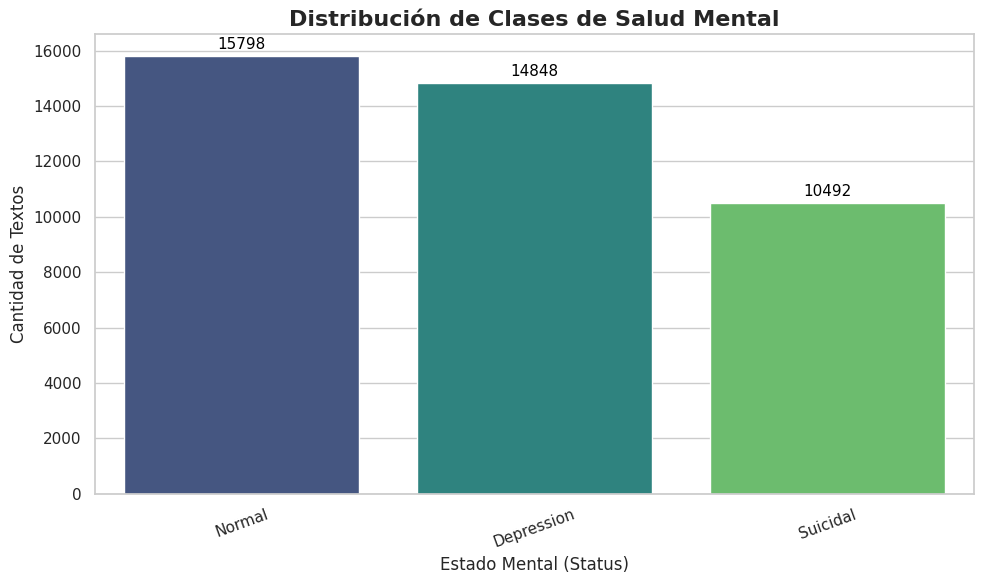

In [15]:
#Distribución de Clases (Balanceo del Target)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
orden_clases = df['status'].value_counts().index

ax = sns.countplot(data=df, x='status', order=orden_clases, hue='status', palette='viridis', legend=False)

plt.title('Distribución de Clases de Salud Mental', fontsize=16, fontweight='bold')
plt.xlabel('Estado Mental (Status)', fontsize=12)
plt.ylabel('Cantidad de Textos', fontsize=12)
plt.xticks(rotation=20)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

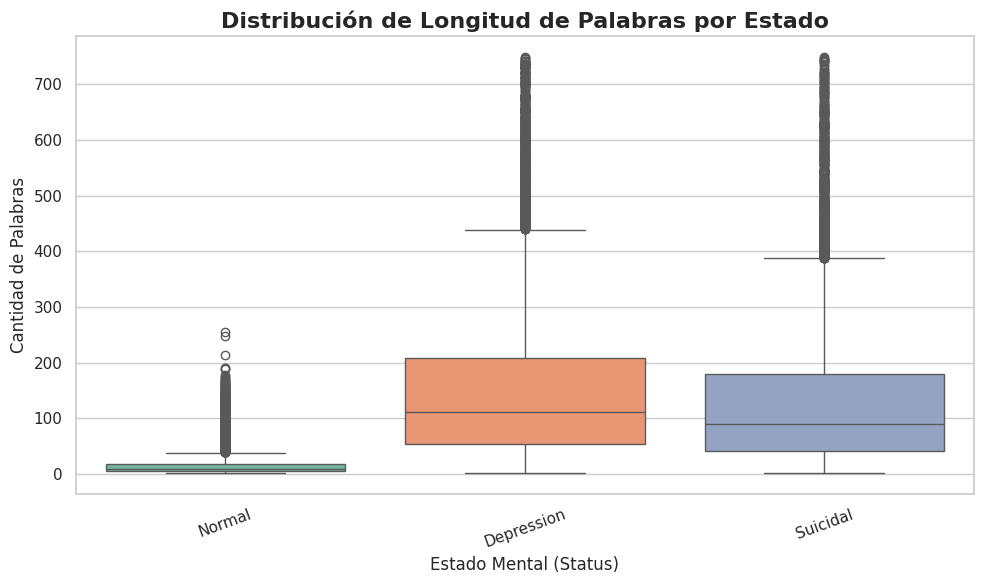

In [16]:
#Longitud del Texto por Estado Mental
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='status', y='word_count', order=orden_clases, hue='status',palette='Set2', legend=False)

plt.title('Distribución de Longitud de Palabras por Estado', fontsize=16, fontweight='bold')
plt.xlabel('Estado Mental (Status)', fontsize=12)
plt.ylabel('Cantidad de Palabras', fontsize=12)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [17]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_and_tokenize(text):
    words = str(text).split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and len(w) > 1]
    return words

df['tokens'] = df['statement_clean'].apply(clean_and_tokenize)
print("Paso 1 — Tokenización inicial completada (stopwords NLTK + lematización, sin palabras_ruido).")

Paso 1 — Tokenización inicial completada (stopwords NLTK + lematización, sin palabras_ruido).


--- EDA 1: TOP 15 PALABRAS MÁS FRECUENTES POR CLASE ---


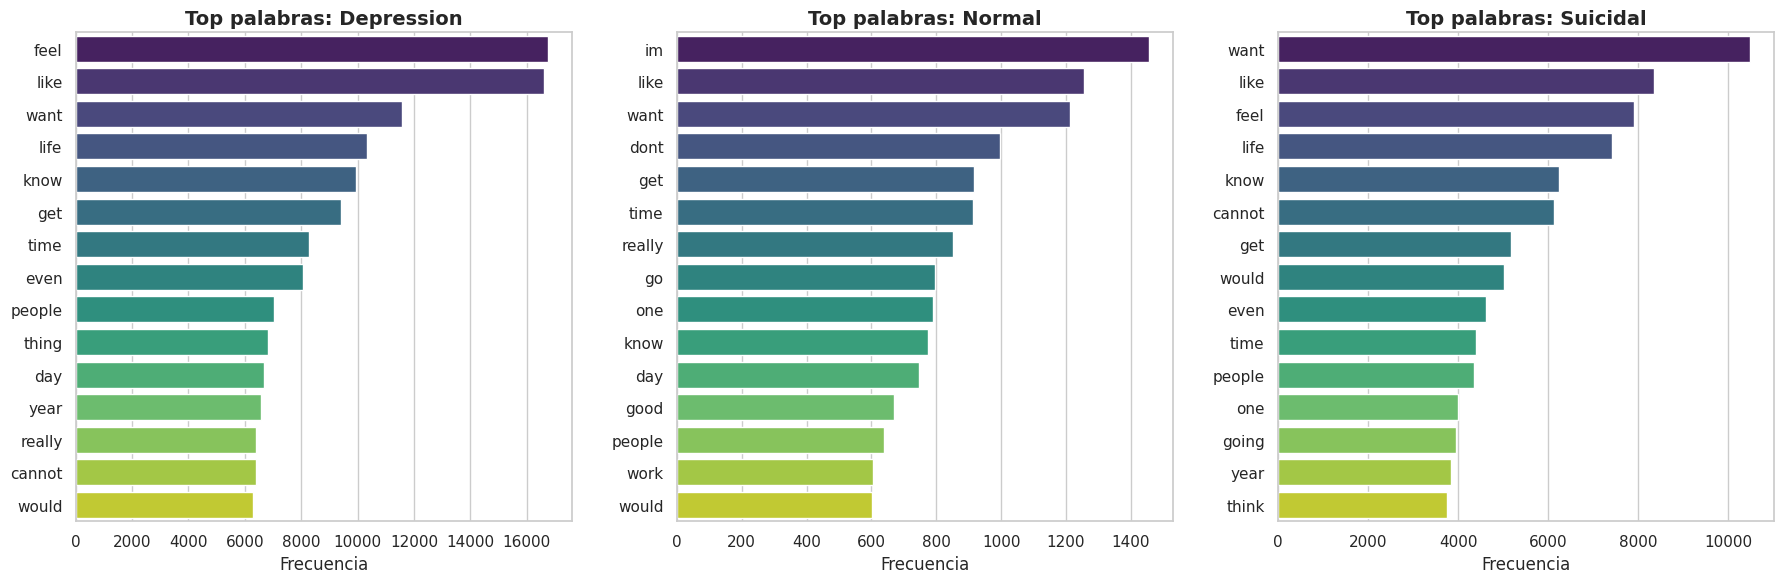

In [18]:
print("--- EDA 1: TOP 15 PALABRAS MÁS FRECUENTES POR CLASE ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.set_theme(style="whitegrid")

for i, clase in enumerate(clases_top3):
    todas_palabras = []
    for tokens in df[df['status'] == clase]['tokens']:
        todas_palabras.extend(tokens)

    conteo = Counter(todas_palabras).most_common(15)
    df_conteo = pd.DataFrame(conteo, columns=['Palabra', 'Frecuencia'])

    sns.barplot(data=df_conteo, x='Frecuencia', y='Palabra', ax=axes[i],
                hue='Palabra', palette='viridis', legend=False)
    axes[i].set_title(f'Top palabras: {clase}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Frecuencia')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [19]:
# Palabras ruido identificadas del EDA 1 (aparecen en el top de las 3 clases)
# + artefactos de contracciones sin apóstrofe producto del preprocesamiento
palabras_ruido = [
    'like', 'want', 'know', 'get', 'really', 'time',
    'people', 'would', 'one', 'even', 'going', 'go',
    'im', 'dont', 'cant'
]

stop_words = set(stopwords.words('english')).union(palabras_ruido)
df['tokens'] = df['statement_clean'].apply(clean_and_tokenize)
print("Paso 3 — Re-tokenización con palabras_ruido completada.")
print(f"Palabras_ruido aplicadas: {palabras_ruido}")

Paso 3 — Re-tokenización con palabras_ruido completada.
Palabras_ruido aplicadas: ['like', 'want', 'know', 'get', 'really', 'time', 'people', 'would', 'one', 'even', 'going', 'go', 'im', 'dont', 'cant']


--- EDA 2: TOP 10 PARES DE PALABRAS (BIGRAMAS) POR CLASE ---


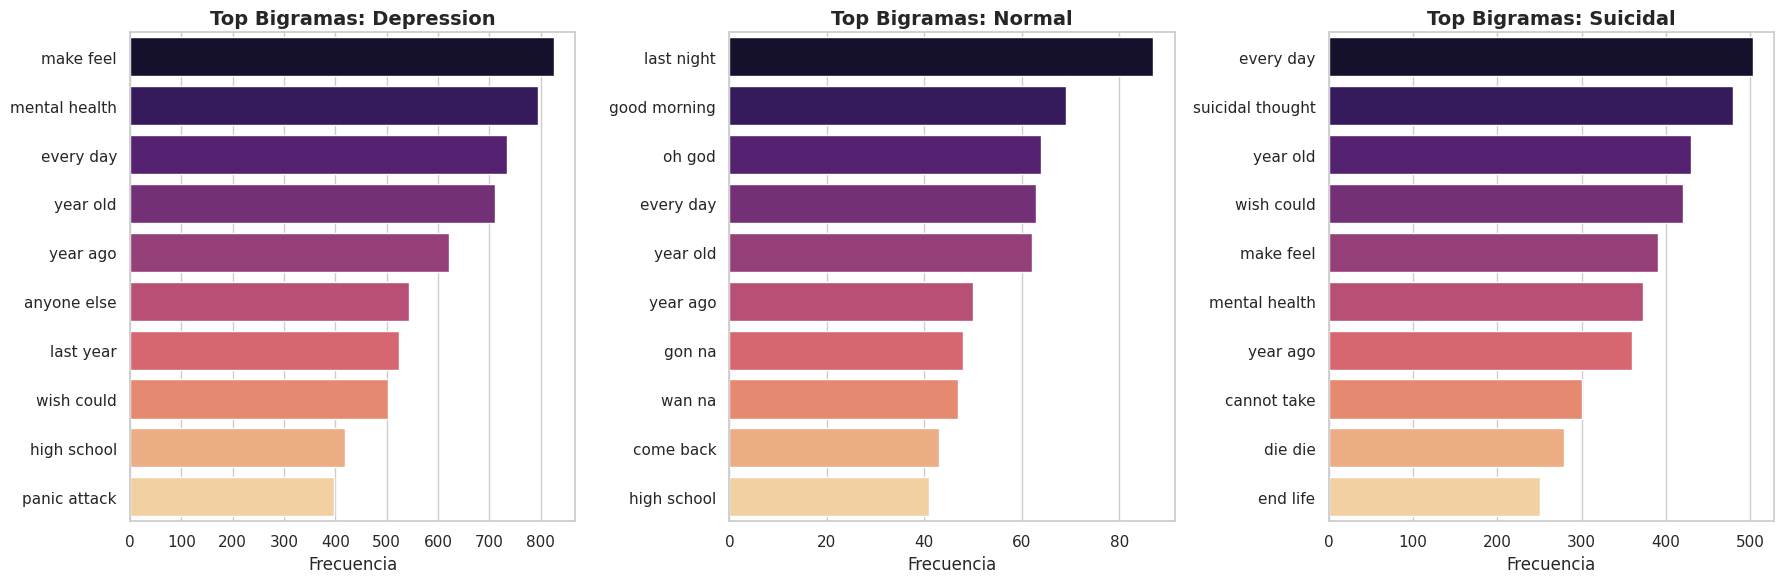

In [20]:
from nltk import bigrams

print("--- EDA 2: TOP 10 PARES DE PALABRAS (BIGRAMAS) POR CLASE ---")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, clase in enumerate(clases_top3):
    todos_bigramas = []
    for tokens in df[df['status'] == clase]['tokens']:
        pares = list(bigrams(tokens))
        pares_str = [" ".join(par) for par in pares]
        todos_bigramas.extend(pares_str)

    conteo_bi = Counter(todos_bigramas).most_common(10)
    df_conteo_bi = pd.DataFrame(conteo_bi, columns=['Bigrama', 'Frecuencia'])

    sns.barplot(data=df_conteo_bi, x='Frecuencia', y='Bigrama', ax=axes[i],
                hue='Bigrama', palette='magma', legend=False)
    axes[i].set_title(f'Top Bigramas: {clase}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Frecuencia')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

--- EDA 3: ANÁLISIS DE SENTIMIENTO (POLARIDAD) ---
Calculando sentimientos... (Esto puede tomar un par de minutos)


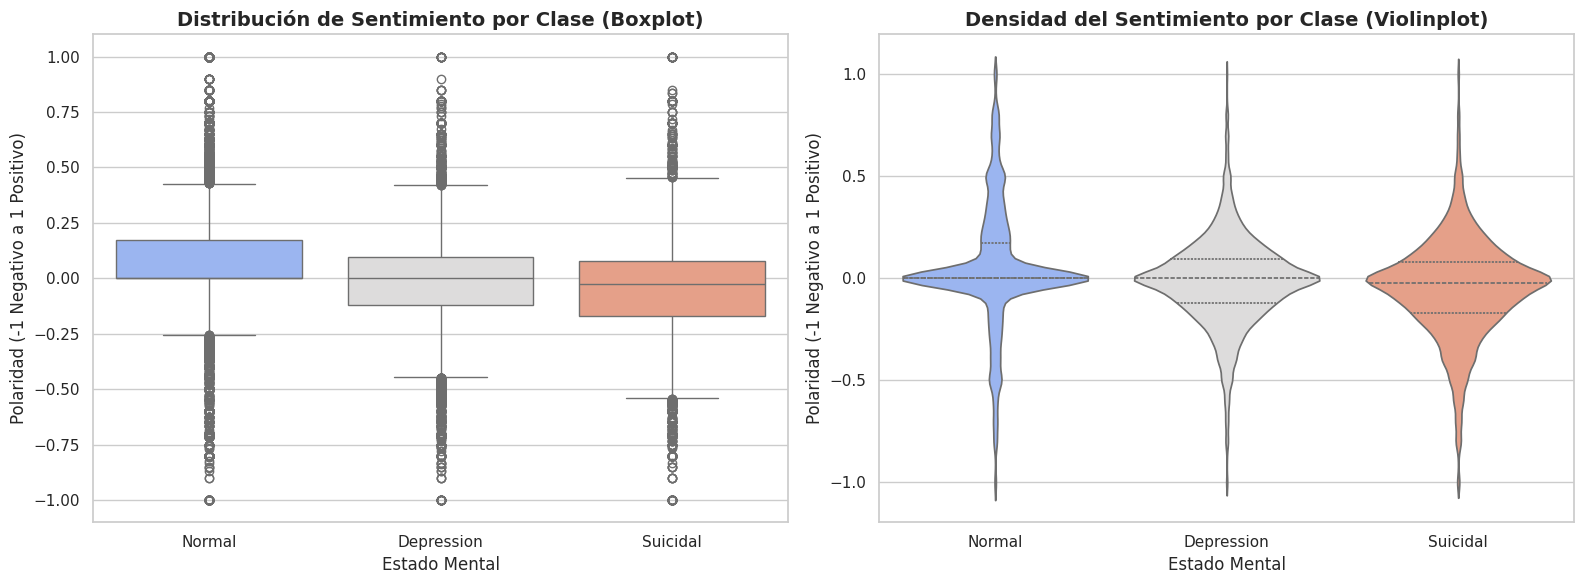


Promedio matemático de sentimiento por clase:


status
Depression   -0.0167
Normal        0.0509
Suicidal     -0.0489
Name: polaridad, dtype: float64

In [ ]:
from textblob import TextBlob

print("--- EDA 3: ANÁLISIS DE SENTIMIENTO (POLARIDAD) ---")

def calcular_polaridad(texto):
    return TextBlob(str(texto)).sentiment.polarity

print("Calculando sentimientos...")
df['polaridad'] = df['tokens'].apply(lambda x: calcular_polaridad(' '.join(x)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

sns.boxplot(data=df, x='status', y='polaridad', hue='status', palette='coolwarm', legend=False, ax=axes[0])
axes[0].set_title('Distribución de Sentimiento por Clase (Boxplot)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Polaridad (-1 Negativo a 1 Positivo)')
axes[0].set_xlabel('Estado Mental')

sns.violinplot(data=df, x='status', y='polaridad', hue='status', palette='coolwarm', inner='quartile', legend=False, ax=axes[1])
axes[1].set_title('Densidad del Sentimiento por Clase (Violinplot)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Polaridad (-1 Negativo a 1 Positivo)')
axes[1].set_xlabel('Estado Mental')

plt.tight_layout()
plt.show()

print("\nPromedio matemático de sentimiento por clase:")
display(df.groupby('status')['polaridad'].mean().round(4))

In [ ]:
#df_fullclean = 'datos/mental_health_cleaned.csv'
#df.to_csv(df_fullclean, index=False)

#print(f"--- PROCESO DE EXPORTACIÓN COMPLETADO ---")
#print(f"El dataset limpio con {df.shape[0]} filas ha sido guardado como: {df_fullclean}")

--- EDA 4: IMPORTANCIA DE PALABRAS POR TF-IDF ---


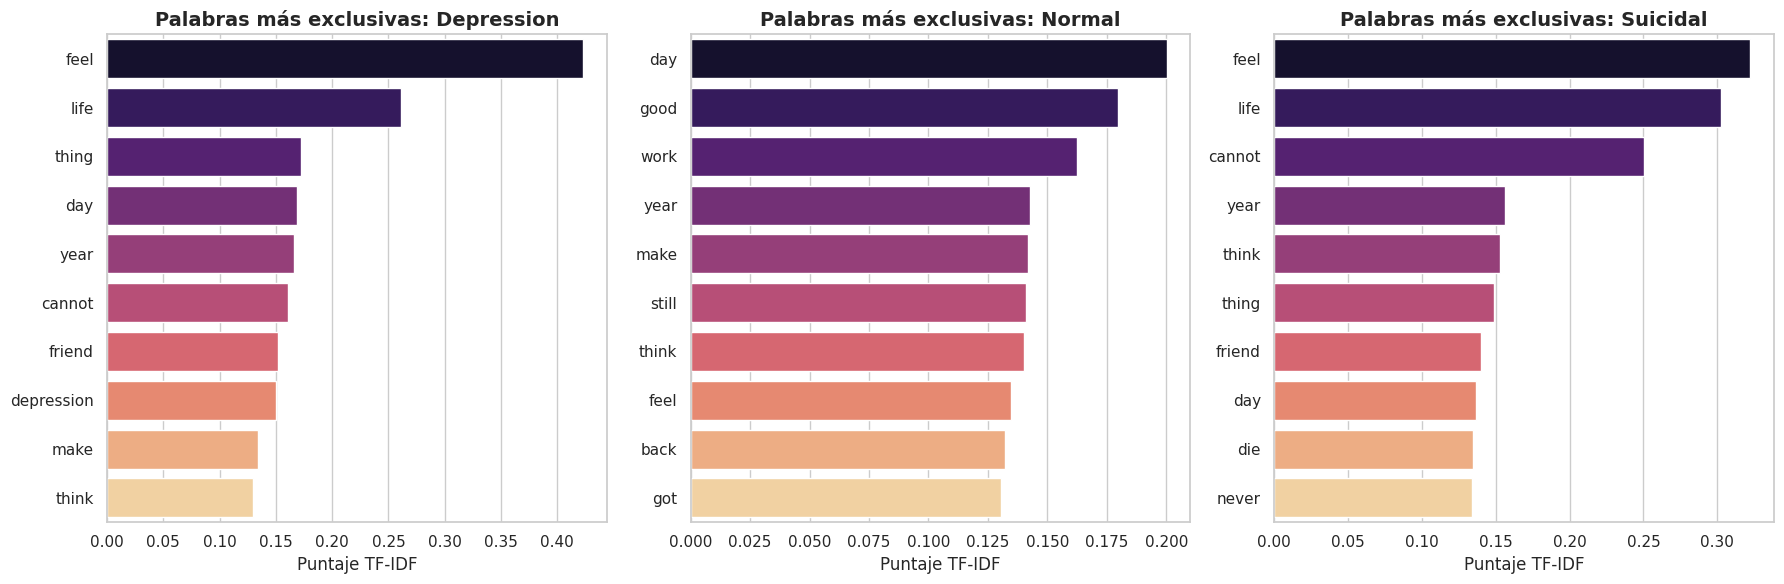

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("--- EDA 4: IMPORTANCIA DE PALABRAS POR TF-IDF ---")

textos_por_clase = df.groupby('status')['tokens'].apply(
    lambda x: ' '.join([' '.join(t) for t in x])
).reset_index()
textos_por_clase.columns = ['status', 'texto']

tfidf = TfidfVectorizer(max_features=1000)
matriz_tfidf = tfidf.fit_transform(textos_por_clase['texto'])

df_tfidf = pd.DataFrame(matriz_tfidf.toarray(), columns=tfidf.get_feature_names_out())
df_tfidf.index = textos_por_clase['status']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.set_theme(style="whitegrid")

for i, clase in enumerate(clases_top3):
    top_palabras = df_tfidf.loc[clase].sort_values(ascending=False).head(10)
    sns.barplot(x=top_palabras.values, y=top_palabras.index, ax=axes[i],
                hue=top_palabras.index, palette='magma', legend=False)
    axes[i].set_title(f'Palabras más exclusivas: {clase}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Puntaje TF-IDF')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

--- EDA 5: MATRIZ DE CORRELACIÓN DE VARIABLES NUMÉRICAS ---


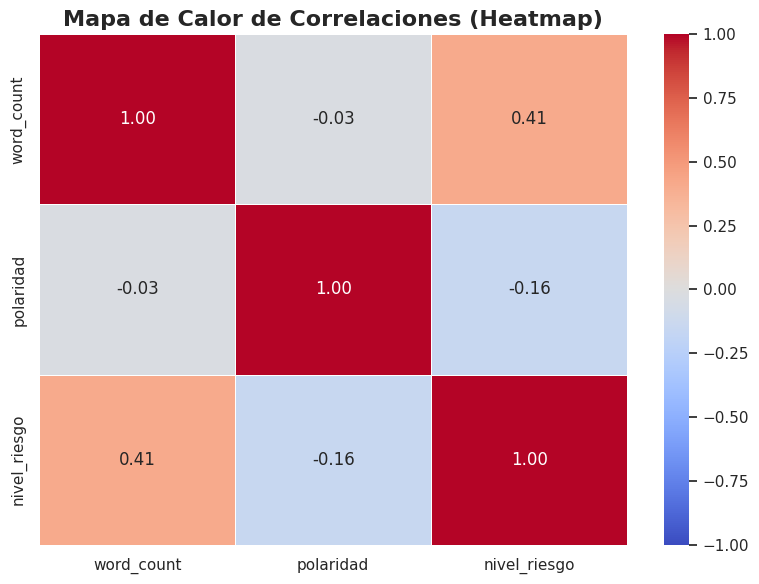

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- EDA 5: MATRIZ DE CORRELACIÓN DE VARIABLES NUMÉRICAS ---")

# 1. Crear una escala numérica para el riesgo clínico
diccionario_riesgo = {'Normal': 0, 'Depression': 1, 'Suicidal': 2}
df['nivel_riesgo'] = df['status'].map(diccionario_riesgo)

# 2. Seleccionar solo las columnas numéricas para la correlación
variables_numericas = df[['word_count', 'polaridad', 'nivel_riesgo']]

# 3. Calcular la matriz de correlación de Pearson
matriz_correlacion = variables_numericas.corr()

# 4. Visualizar usando un Heatmap de Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            fmt=".2f", linewidths=0.5, annot_kws={"size": 12})

plt.title('Mapa de Calor de Correlaciones (Heatmap)', fontsize=16, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

--- EDA 6: DISTRIBUCIÓN DE LONGITUD POR CLASE ---


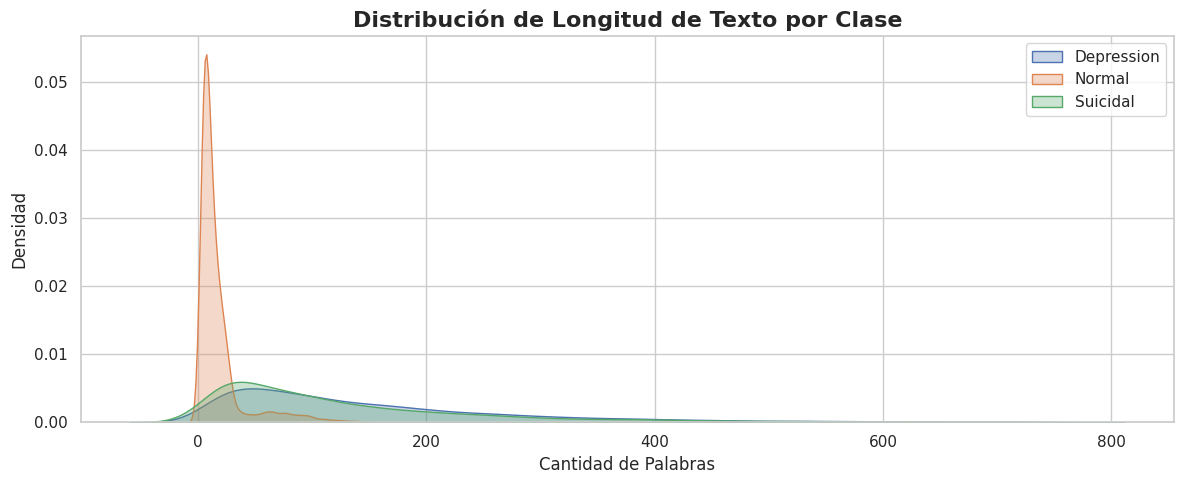

              count   mean    std  min   25%    50%    75%    max
status                                                           
Depression  14848.0  153.0  136.5  2.0  54.0  111.0  208.0  749.0
Normal      15798.0   17.7   22.9  2.0   6.0   10.0   19.0  255.0
Suicidal    10492.0  133.2  130.4  2.0  41.0   90.0  180.0  750.0


In [25]:
print("--- EDA 6: DISTRIBUCIÓN DE LONGITUD POR CLASE ---")

plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid")

for clase in clases_top3:
    datos = df[df['status'] == clase]['word_count']
    sns.kdeplot(datos, label=clase, fill=True, alpha=0.3)

plt.title('Distribución de Longitud de Texto por Clase', fontsize=16,
fontweight='bold')
plt.xlabel('Cantidad de Palabras')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

print(df.groupby('status')['word_count'].describe().round(1))

--- EDA 7: RIQUEZA LÉXICA POR CLASE ---


,Clase,Total palabras,Palabras únicas,Ratio
0,Depression,900311,35343,0.0393
1,Normal,131536,20478,0.1557
2,Suicidal,542734,26532,0.0489


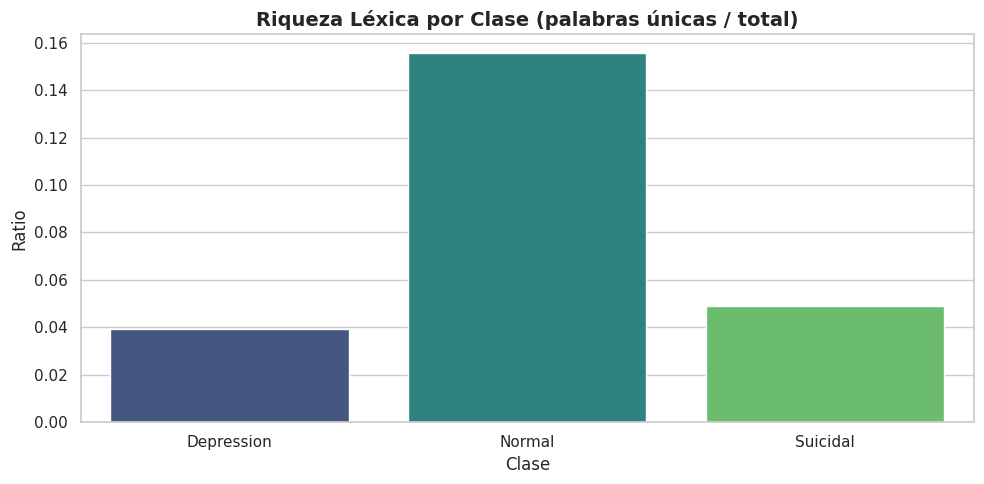

In [26]:
print("--- EDA 7: RIQUEZA LÉXICA POR CLASE ---")

fig, ax = plt.subplots(figsize=(10, 5))
sns.set_theme(style="whitegrid")
resultados = []
for clase in clases_top3:
    todas_palabras = []
    for tokens in df[df['status'] == clase]['tokens']:
        todas_palabras.extend(tokens)
    total = len(todas_palabras)
    unicas = len(set(todas_palabras))
    ratio = unicas / total
    resultados.append({'Clase': clase, 'Total palabras': total,
                       'Palabras únicas': unicas, 'Ratio':
round(ratio, 4)})
df_riqueza = pd.DataFrame(resultados)
display(df_riqueza)
sns.barplot(data=df_riqueza, x='Clase', y='Ratio', hue='Clase',
palette='viridis', legend=False)
ax.set_title('Riqueza Léxica por Clase (palabras únicas / total)',
fontsize=14, fontweight='bold')
ax.set_ylabel('Ratio')
ax.set_xlabel('Clase')
plt.tight_layout()
plt.show()